In [39]:
import pandas as pd
import os
import glob
import ast

In [40]:
def single(filepath):
    df = pd.read_csv(filepath)
    df = df[df['target_col'].notna()].copy()
    
    df['mouse.time'] = df['mouse.time'].apply(ast.literal_eval)
    df['mouse.clicked_name'] = df['mouse.clicked_name'].apply(ast.literal_eval)
    
    rts = []
    accuracies = []
    for idx, row in df.iterrows():
        onset = row['mouse.started']
        click_times = row['mouse.time']
        click_names = row['mouse.clicked_name']
        
        if len(click_times) > 0:  # at least one click
            rt = click_times[0] - onset   # first click RT
            correct = 1 if click_names[0] == 'target' else 0
            rts.append(rt)
            accuracies.append(correct)
        else:
            # No response – treat as incorrect, RT missing
            accuracies.append(0)
            # No RT appended
    
    # Compute participant-level means
    lab_mean_rt = pd.Series(rts).mean() if rts else float('nan')
    lab_mean_acc = pd.Series(accuracies).mean()
    
    participant_id = int(os.path.basename(filepath).split('_')[0])

    df = pd.read_csv('data_brsm/single/phone/' + str(participant_id) + '_attentional_spotter_results.csv')

    phone_rt = df['InitialResponseTime(ms)'].tolist()
    phone_acc = df['HitRate(%)'].tolist()
    
    phone_mean_rt = 0.0
    phone_accuracy = 0.0
    for i in range(len(phone_rt)):
        phone_mean_rt += phone_rt[i]
        phone_accuracy += phone_acc[i]
    phone_mean_rt /= 1000*len(phone_rt)
    phone_accuracy /= 100*len(phone_rt)
    
    return participant_id, lab_mean_rt, lab_mean_acc, phone_mean_rt, phone_accuracy

In [41]:
results = []
folder = f'data_brsm/single/lab'
csv_files = glob.glob(os.path.join(folder, '*.csv'))
for file in csv_files:
    #print(file)
    pid, lab_rt, lab_acc, phone_rt, phone_acc = single(file)
    results.append({
        'participant': pid,
        'group': 0,
        'modality': 1,
        'lab_RT': lab_rt,
        'lab_Accuracy': lab_acc,
        'phone_RT': phone_rt,
        'phone_Accuracy': phone_acc
    })

# Convert to DataFrame
data = pd.DataFrame(results)

# Check that each participant has both modalities
pivot = data.pivot(index='participant', columns='modality', values=['lab_RT', 'lab_Accuracy', 'phone_RT', 'phone_Accuracy'])
# If any missing, you may need to exclude those participants
data = data.dropna(subset=['lab_RT', 'lab_Accuracy', 'phone_RT', 'phone_Accuracy'])  # or handle missing

data.head()

,participant,group,modality,lab_RT,lab_Accuracy,phone_RT,phone_Accuracy
0,12,0,1,1.425327,1.0,2.649333,1.000000
1,17,0,1,1.106670,1.0,2.426733,1.000000
2,18,0,1,1.482725,1.0,2.616750,0.937500
3,5,0,1,1.438456,1.0,3.696789,0.789474
4,20,0,1,1.436397,1.0,3.487933,1.000000


In [42]:
def process_data(filepath, group):
    df = pd.read_csv(filepath)
    df = df[df['target_col'].notna()].copy()
    
    df['mouse.time'] = df['mouse.time'].apply(ast.literal_eval)
    df['mouse.clicked_name'] = df['mouse.clicked_name'].apply(ast.literal_eval)
    
    rts = []
    accuracies = []
    for idx, row in df.iterrows():
        onset = row['mouse.started']
        click_times = row['mouse.time']
        click_names = row['mouse.clicked_name']
        
        if len(click_times) > 0:  # at least one click
            rt = click_times[0] - onset   # first click RT
            
            if group == 'multiple':
                # For multiple, all clicks must be on a target
                correct = 1 if all(name.startswith('target') for name in click_names) else 0
            else:
                # For single, only the first click matters
                correct = 1 if click_names[0].startswith('target') else 0
            
            rts.append(rt)
            accuracies.append(correct)
        else:
            # No response – treat as incorrect, RT missing
            accuracies.append(0)
            # No RT appended
    
    # Compute participant-level means
    lab_mean_rt = pd.Series(rts).mean() if rts else float('nan')
    lab_mean_acc = pd.Series(accuracies).mean()
    
    participant_id = int(os.path.basename(filepath).split('_')[0])

    phone_file = f'data_brsm/{group}/phone/{participant_id}_attentional_spotter_results.csv'
    df_phone = pd.read_csv(phone_file)

    phone_rt = df_phone['InitialResponseTime(ms)'].tolist()
    phone_acc = df_phone['HitRate(%)'].tolist()
    
    phone_mean_rt = pd.Series(phone_rt).mean() / 1000
    phone_accuracy = pd.Series(phone_acc).mean() / 100
    
    return participant_id, lab_mean_rt, lab_mean_acc, phone_mean_rt, phone_accuracy

results = []
for group, group_name in [(0, 'single'), (1, 'multiple')]:
    folder = f'data_brsm/{group_name}/lab'
    csv_files = glob.glob(os.path.join(folder, '*.csv'))
    for file in csv_files:
        pid, lab_rt, lab_acc, phone_rt, phone_acc = process_data(file, group_name)
        results.append({
            'participant': pid,
            'group': group,
            'lab_RT': lab_rt,
            'lab_Accuracy': lab_acc,
            'phone_RT': phone_rt,
            'phone_Accuracy': phone_acc
        })

# Convert to DataFrame
data = pd.DataFrame(results)

# Check that each participant has both modalities
data = data.dropna(subset=['lab_RT', 'lab_Accuracy', 'phone_RT', 'phone_Accuracy'])  # or handle missing

data.head()

,participant,group,lab_RT,lab_Accuracy,phone_RT,phone_Accuracy
0,12,0,1.425327,1.0,2.649333,1.000000
1,17,0,1.106670,1.0,2.426733,1.000000
2,18,0,1.482725,1.0,2.616750,0.937500
3,5,0,1.438456,1.0,3.696789,0.789474
4,20,0,1.436397,1.0,3.487933,1.000000


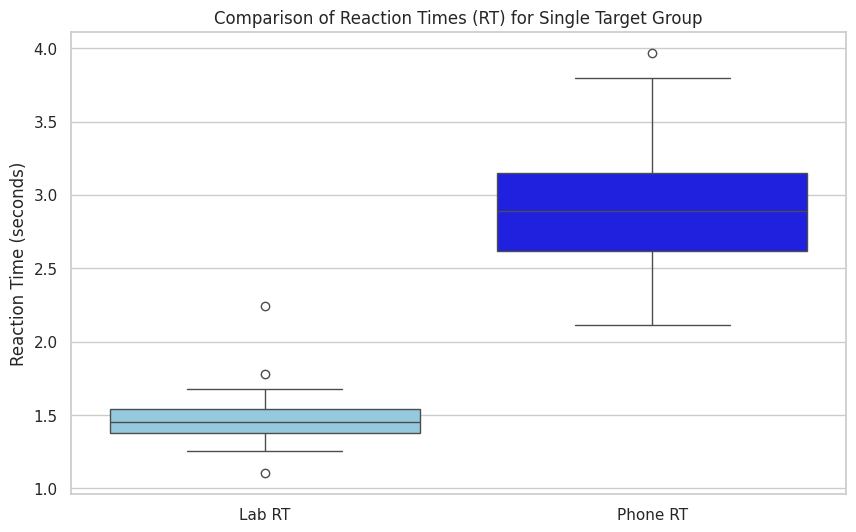

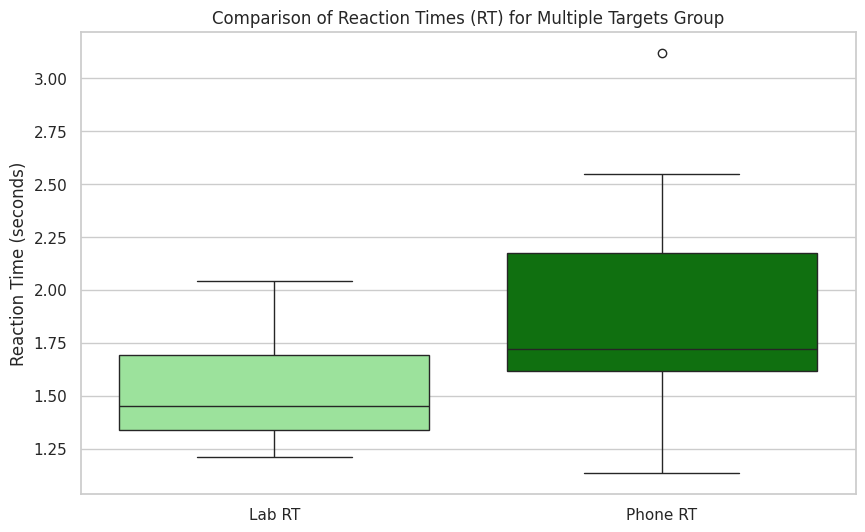

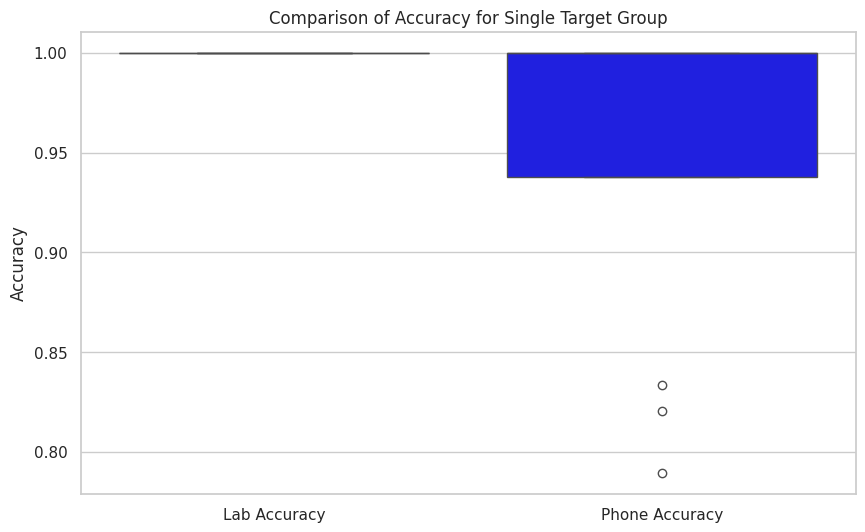

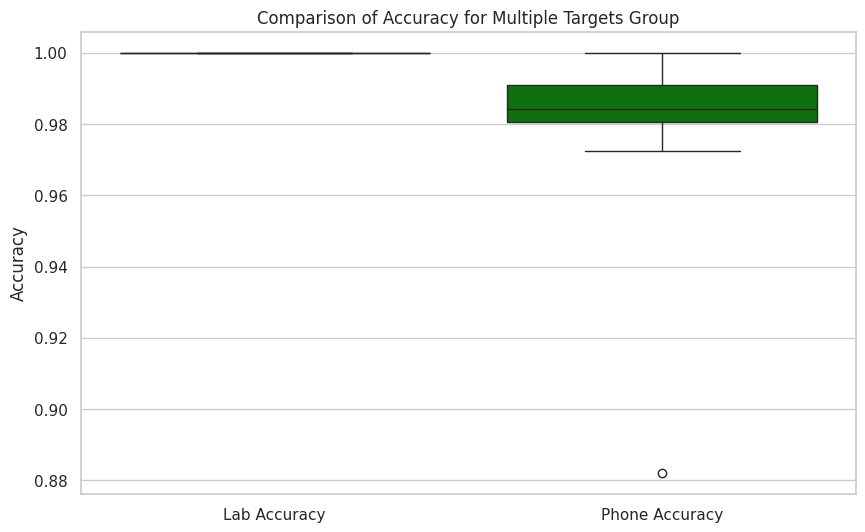

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set the style of the visualization
sns.set(style="whitegrid")

# Separate data for single and multiple groups
single_data = data[data['group'] == 0]
multiple_data = data[data['group'] == 1]

# 1. Compare RTs for Single Target Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=[single_data['lab_RT'].dropna(), single_data['phone_RT'].dropna()], palette=['skyblue', 'blue'])
plt.title('Comparison of Reaction Times (RT) for Single Target Group')
plt.ylabel('Reaction Time (seconds)')
plt.xticks([0, 1], ['Lab RT', 'Phone RT'])
plt.show()

# 2. Compare RTs for Multiple Targets Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=[multiple_data['lab_RT'].dropna(), multiple_data['phone_RT'].dropna()], palette=['lightgreen', 'green'])
plt.title('Comparison of Reaction Times (RT) for Multiple Targets Group')
plt.ylabel('Reaction Time (seconds)')
plt.xticks([0, 1], ['Lab RT', 'Phone RT'])
plt.show()

# 3. Compare Accuracy for Single Target Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=[single_data['lab_Accuracy'].dropna(), single_data['phone_Accuracy'].dropna()], palette=['skyblue', 'blue'])
plt.title('Comparison of Accuracy for Single Target Group')
plt.ylabel('Accuracy')
plt.xticks([0, 1], ['Lab Accuracy', 'Phone Accuracy'])
plt.show()

# 4. Compare Accuracy for Multiple Targets Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=[multiple_data['lab_Accuracy'].dropna(), multiple_data['phone_Accuracy'].dropna()], palette=['lightgreen', 'green'])
plt.title('Comparison of Accuracy for Multiple Targets Group')
plt.ylabel('Accuracy')
plt.xticks([0, 1], ['Lab Accuracy', 'Phone Accuracy'])
plt.show()